In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [21]:
df = pd.read_csv("house_prices_540.csv")

In [22]:
df.head()

,House_ID,Area_sqft,Bedrooms,Price_Lakhs
0,H0001,2237,4,75
1,H0002,618,3,68
2,H0003,3044,3,32
3,H0004,1600,1,80
4,H0005,1450,4,68


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540 entries, 0 to 539
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   House_ID     540 non-null    object
 1   Area_sqft    540 non-null    int64 
 2   Bedrooms     540 non-null    int64 
 3   Price_Lakhs  540 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 17.0+ KB


In [24]:
df.describe()

,Area_sqft,Bedrooms,Price_Lakhs
count,540.000000,540.000000,540.000000
mean,2078.692593,3.046296,68.151852
std,866.441136,1.399604,27.375746
min,601.000000,1.000000,20.000000
25%,1314.000000,2.000000,46.000000
50%,2102.000000,3.000000,67.000000
75%,2894.750000,4.000000,91.000000
max,3489.000000,5.000000,119.000000


In [25]:
df.columns

Index(['House_ID', 'Area_sqft', 'Bedrooms', 'Price_Lakhs'], dtype='object')

In [26]:
X = df[['Area_sqft', 'Bedrooms']]

In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [28]:
z = linkage(X_scaled, method='ward')

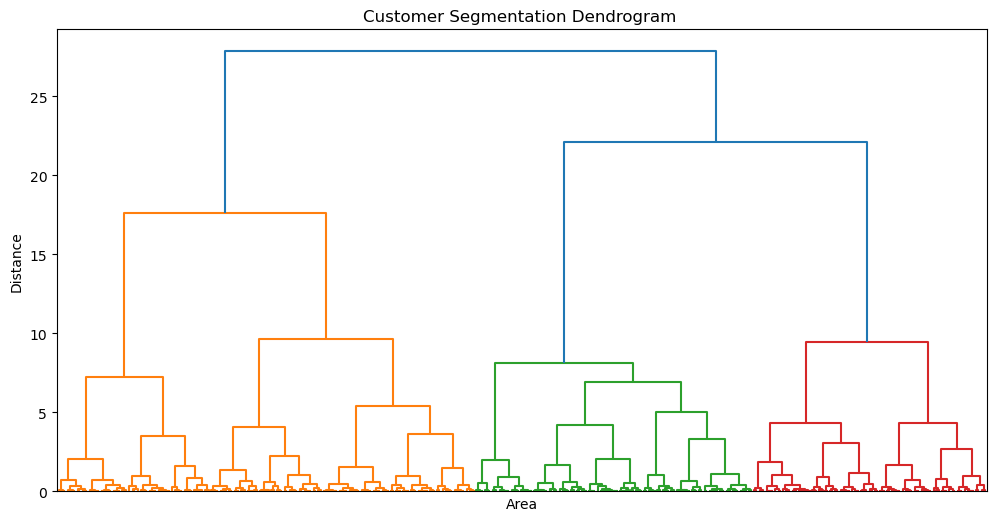

In [29]:
plt.figure(figsize=(12,6))
dendrogram(z, no_labels=True)
plt.title("Customer Segmentation Dendrogram ")
plt.xlabel("Area")
plt.ylabel("Distance")
plt.show()

In [30]:
hc = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

df["Cluster"] = hc.fit_predict(X_scaled)


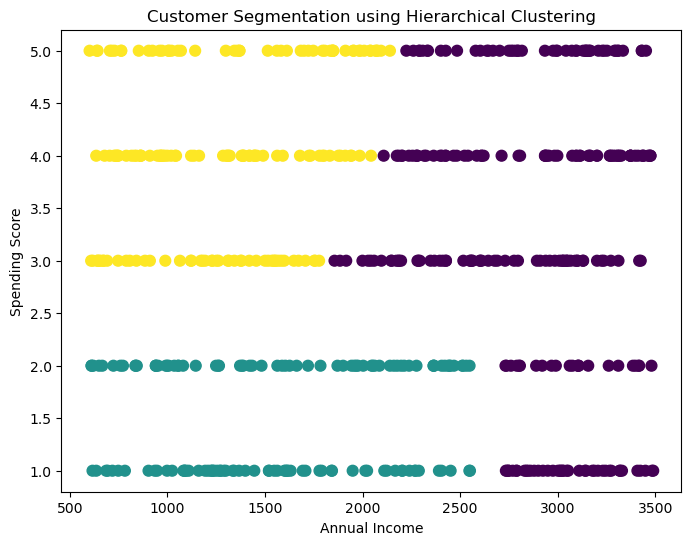

In [31]:
plt.figure(figsize=(8,6))
plt.scatter(
    df["Area_sqft"],
    df["Bedrooms"],
    c=df["Cluster"],
    s=60
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using Hierarchical Clustering")
plt.show()
